This notebook demonstrates the use of the `analyse_moves` function which gives an overview of the scoring consequences of all moves from a given position

Specifically, it gives an output that shows for each move from a given position:
- what the relative score (with optimal) play following that move is compared to the optimal score
- what the impact to each player's score is, ie: does it add more points to your hand or take away points from the opponent

This is intended to help develop an understanding of what good strategy looks like, whether to focus on offensive or defensive play

Note that the comparison here is entirely based on the average point totals, not the win/draw/lose chances

In [1]:
from cardgame import Game, analyse_moves, ProbEval, Card
import matplotlib as mpl
import matplotlib.pylab as plt
import seaborn as sns
from random import choice, seed
import pandas as pd
from ipywidgets import interact
from IPython.display import display

sns.set_style("darkgrid")
plt.style.use("dark_background")

In [2]:
# This is a game that is played optimally from move 17
seed(10)
curr_game = Game.load(
    "??3♠7♦8♥4♥??/5♦??A♠K♣??3♦/5♠K♦????5♣6♣/8♠4♦????8♣4♠/2♦??A♥7♥??K♠/??2♣A♣7♣7♠??//4♣2♠A♦K♥6♦3♣5♥6♠6♥3♥2♥8♦//"
)
moves = [
    (2, 1),
    (3, 1),
    (3, 2),
    (3, 5),
    (4, 5),
    (5, 5),
    (0, 5),
    (0, 4),
    (2, 4),
    (2, 0),
    (1, 0),
    (1, 3),
    (2, 3),
    (3, 3),
    (5, 3),
    (5, 0),
    (0, 0),
    (0, 1),  # <- This move and all following are optimal
    (5, 1),
    (5, 4),
    (1, 4),
    (1, 1),
    (1, 5),
    (2, 5),
    (2, 2),
    (4, 2),
    (4, 1),
    (4, 4),
    (3, 4),
    (3, 0),
    (4, 0),
    (4, 3),
    (0, 3),
    (0, 2),
    (5, 2),
    (1, 2),
]
for move in moves:
    curr_game = choice(curr_game.move(*move))


@interact(moves=(0, 36))
def show_game(moves=0):
    display(curr_game.undo(36 - moves))

interactive(children=(IntSlider(value=0, description='moves', max=36), Output()), _dom_classes=('widget-intera…

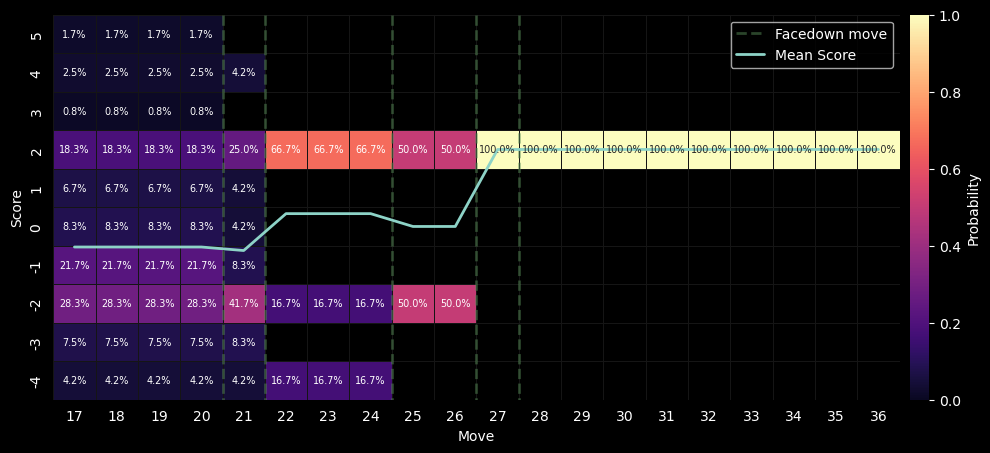

In [3]:
# The expected score and possible outcomes with optimal play, calculated from move 17
game_evals = [
    ProbEval(
        multiplicity=120,
        initial_counts={
            -4: 5,
            -3: 9,
            -2: 34,
            -1: 26,
            0: 10,
            1: 8,
            2: 22,
            3: 1,
            4: 3,
            5: 2,
        },
    ),  # 19
    ProbEval(
        multiplicity=120,
        initial_counts={
            -4: 5,
            -3: 9,
            -2: 34,
            -1: 26,
            0: 10,
            1: 8,
            2: 22,
            3: 1,
            4: 3,
            5: 2,
        },
    ),
    ProbEval(
        multiplicity=120,
        initial_counts={
            -4: 5,
            -3: 9,
            -2: 34,
            -1: 26,
            0: 10,
            1: 8,
            2: 22,
            3: 1,
            4: 3,
            5: 2,
        },
    ),
    ProbEval(
        multiplicity=120,
        initial_counts={
            -4: 5,
            -3: 9,
            -2: 34,
            -1: 26,
            0: 10,
            1: 8,
            2: 22,
            3: 1,
            4: 3,
            5: 2,
        },
    ),
    ProbEval(
        multiplicity=24,
        initial_counts={-4: 1, -3: 2, -2: 10, -1: 2, 0: 1, 1: 1, 2: 6, 4: 1},
    ),
    ProbEval(multiplicity=6, initial_counts={-4: 1, -2: 1, 2: 4}),
    ProbEval(multiplicity=6, initial_counts={-4: 1, -2: 1, 2: 4}),
    ProbEval(multiplicity=6, initial_counts={-4: 1, -2: 1, 2: 4}),
    ProbEval(multiplicity=2, initial_counts={-2: 1, 2: 1}),
    ProbEval(multiplicity=2, initial_counts={-2: 1, 2: 1}),
    ProbEval(multiplicity=1, initial_counts={2: 1}),
    ProbEval(multiplicity=1, initial_counts={2: 1}),
    ProbEval(multiplicity=1, initial_counts={2: 1}),
    ProbEval(multiplicity=1, initial_counts={2: 1}),
    ProbEval(multiplicity=1, initial_counts={2: 1}),
    ProbEval(multiplicity=1, initial_counts={2: 1}),
    ProbEval(multiplicity=1, initial_counts={2: 1}),
    ProbEval(multiplicity=1, initial_counts={2: 1}),
    ProbEval(multiplicity=1, initial_counts={2: 1}),
    ProbEval(multiplicity=1, initial_counts={2: 1}),
]
moves_fd_card_was_taken = (21, 22, 25, 27, 28)

evaluation_state = curr_game.undo(19)
move_index_base = len(evaluation_state.moves)
fig, ax = plt.subplots(figsize=(13, 5))
ax.grid(visible=None)

# Format the score data to name indexes and include missing values
df = pd.DataFrame(game_evals).T.sort_index(ascending=False)
df.columns = df.columns = pd.RangeIndex(
    start=move_index_base, stop=move_index_base + len(game_evals), name="Move"
)
df.columns = pd.RangeIndex(
    start=move_index_base, stop=move_index_base + len(game_evals), name="Move"
)
df = df.reindex(
    pd.RangeIndex(start=max(df.index), stop=min(df.index) - 1, step=-1, name="Score")
)

# Use a heatmap to show how likely each outcome is evaluated as being from each point in the game history
sns.heatmap(
    df / df.sum(),
    cmap=mpl.colors.ListedColormap(
        mpl.colormaps["magma"].colors[16:]
    ),  # Drop the darkest part of the colormap to more clearly separate possible/impossible values
    linewidths=0.6,
    linecolor="#151515",
    cbar_kws={"pad": 0.01, "label": "Probability"},
    vmin=0,
    vmax=1,
    ax=ax,
    annot=True,
    fmt=".1%",
    annot_kws={"fontsize": "x-small"},
)

# Add marks to highlight where facedown moves were made, and what the mean score difference is for the possible outcomes from each position
ax.vlines(
    x=[mn - move_index_base for mn in moves_fd_card_was_taken],
    ymin=0,
    ymax=df.shape[0],
    colors="#585",
    ls="--",
    lw=2,
    alpha=0.5,
    label="Facedown move",
)
sns.lineplot(
    x=[i + 0.5 for i in range(len(game_evals))],
    y=[
        df.index.max() + 0.5 - (sum(k * v for k, v in scr.items()) / scr.multiplicity)
        for scr in game_evals
    ],
    label="Mean Score",
    linewidth=2,
    ax=ax,
)

plt.show()

In [11]:
def plot_analysis(analysis):
    fig, ax = plt.subplots(figsize=(10, 4))
    best_move_marker, best_move = max(analysis.items(), key=lambda x: x[1]["combined"])
    for marker, data in analysis.items():
        off = data["offensive"]
        defv = data["defensive"]
        comb = data["combined"]
        x = off + defv
        y = comb
        color = "red" if (comb == 0) else "royalblue"
        size = 120 if (comb == 0) else 60
        ax.scatter(x, y, c=color, s=size, zorder=5)
        if (comb != 0) or (x != 0):
            card_str = str(data["card"])
            if card_str == "??":
                card_str = f"FD R{marker[0]}C{marker[1]}"
            ax.annotate(
                card_str, (x, y), textcoords="offset points", xytext=(5, 5), fontsize=12
            )
    card_str = str(best_move["card"])
    if card_str == "??":
        card_str = f"FD R{best_move_marker[0]}C{best_move_marker[1]}"
    ax.set_title(
        f"Best move - {card_str}",
        fontsize=12,
        fontweight="bold",
    )
    ax.set_ylabel("Evaluation difference")
    ax.set_xlabel(
        "<- Lower point totals (offensive)          Same total points         Higher point totals (defensive)->"
    )
    curr = max(abs(bound) for bound in ax.get_xlim())
    ax.set_xlim(-curr, curr)
    plt.grid(axis="x")
    plt.tight_layout()
    plt.show()

In [12]:
# Full move analysis for each position from move 19
analysis_by_moves_undone = {
    2: {
        (1, 2): {
            "card": Card.from_str("A♠"),
            "player_mean": 22.0,
            "opponent_mean": 24.0,
            "mean_diff": -2.0,
            "offensive": 0.0,
            "defensive": 0.0,
            "combined": 0.0,
        },
        (5, 2): {
            "card": Card.from_str("A♣"),
            "player_mean": 22.0,
            "opponent_mean": 24.0,
            "mean_diff": -2.0,
            "offensive": 0.0,
            "defensive": 0.0,
            "combined": 0.0,
        },
    },
    8: {
        (4, 0): {
            "card": Card.from_str("2♦"),
            "player_mean": 19.0,
            "opponent_mean": 23.0,
            "mean_diff": -4.0,
            "offensive": -1.0,
            "defensive": -3.0,
            "combined": -2.0,
        },
        (3, 4): {
            "card": Card.from_str("8♣"),
            "player_mean": 22.0,
            "opponent_mean": 24.0,
            "mean_diff": -2.0,
            "offensive": 0.0,
            "defensive": 0.0,
            "combined": 0.0,
        },
        (4, 3): {
            "card": Card.from_str("7♥"),
            "player_mean": 14.0,
            "opponent_mean": 19.0,
            "mean_diff": -5.0,
            "offensive": -5.0,
            "defensive": -8.0,
            "combined": -3.0,
        },
    },
    9: {
        (4, 4): {
            "card": Card.from_str("??"),
            "player_mean": 24.0,
            "opponent_mean": 22.0,
            "mean_diff": 2.0,
            "offensive": 0.0,
            "defensive": 0.0,
            "combined": 0.0,
        },
        (4, 0): {
            "card": Card.from_str("2♦"),
            "player_mean": 18.0,
            "opponent_mean": 20.0,
            "mean_diff": -2.0,
            "offensive": -2.0,
            "defensive": -6.0,
            "combined": -4.0,
        },
        (4, 3): {
            "card": Card.from_str("7♥"),
            "player_mean": 15.0,
            "opponent_mean": 16.0,
            "mean_diff": -1.0,
            "offensive": -6.0,
            "defensive": -9.0,
            "combined": -3.0,
        },
    },
    10: {
        (4, 4): {
            "card": Card.from_str("??"),
            "player_mean": 17.5,
            "opponent_mean": 19.0,
            "mean_diff": -1.5,
            "offensive": 0.5,
            "defensive": -1.0,
            "combined": -1.5,
        },
        (1, 2): {
            "card": Card.from_str("A♠"),
            "player_mean": 18.5,
            "opponent_mean": 18.5,
            "mean_diff": 0.0,
            "offensive": 0.0,
            "defensive": 0.0,
            "combined": 0.0,
        },
        (4, 0): {
            "card": Card.from_str("2♦"),
            "player_mean": 21.0,
            "opponent_mean": 22.0,
            "mean_diff": -1.0,
            "offensive": 3.5,
            "defensive": 2.5,
            "combined": -1.0,
        },
        (4, 3): {
            "card": Card.from_str("7♥"),
            "player_mean": 15.5,
            "opponent_mean": 17.0,
            "mean_diff": -1.5,
            "offensive": -1.5,
            "defensive": -3.0,
            "combined": -1.5,
        },
        (0, 2): {
            "card": Card.from_str("7♦"),
            "player_mean": 14.0,
            "opponent_mean": 15.0,
            "mean_diff": -1.0,
            "offensive": -3.5,
            "defensive": -4.5,
            "combined": -1.0,
        },
        (4, 1): {
            "card": Card.from_str("??"),
            "player_mean": 19.5,
            "opponent_mean": 19.5,
            "mean_diff": 0.0,
            "offensive": 1.0,
            "defensive": 1.0,
            "combined": 0.0,
        },
        (5, 2): {
            "card": Card.from_str("A♣"),
            "player_mean": 18.5,
            "opponent_mean": 18.5,
            "mean_diff": 0.0,
            "offensive": 0.0,
            "defensive": 0.0,
            "combined": 0.0,
        },
    },
    11: {
        (0, 2): {
            "card": Card.from_str("7♦"),
            "player_mean": 20.5,
            "opponent_mean": 21.0,
            "mean_diff": -0.5,
            "offensive": 2.5,
            "defensive": 2.0,
            "combined": -0.5,
        },
        (1, 2): {
            "card": Card.from_str("A♠"),
            "player_mean": 18.5,
            "opponent_mean": 20.0,
            "mean_diff": -1.5,
            "offensive": 1.5,
            "defensive": 0.0,
            "combined": -1.5,
        },
        (4, 2): {
            "card": Card.from_str("A♥"),
            "player_mean": 18.5,
            "opponent_mean": 18.5,
            "mean_diff": 0.0,
            "offensive": 0.0,
            "defensive": 0.0,
            "combined": 0.0,
        },
        (5, 2): {
            "card": Card.from_str("A♣"),
            "player_mean": 19.5,
            "opponent_mean": 21.0,
            "mean_diff": -1.5,
            "offensive": 2.5,
            "defensive": 1.0,
            "combined": -1.5,
        },
    },
    13: {
        (1, 2): {
            "card": Card.from_str("A♠"),
            "player_mean": 19.0,
            "opponent_mean": 21.0,
            "mean_diff": -2.0,
            "offensive": 3.166666666666668,
            "defensive": 1.5,
            "combined": -1.6666666666666679,
        },
        (2, 5): {
            "card": Card.from_str("6♣"),
            "player_mean": 17.5,
            "opponent_mean": 17.833333333333332,
            "mean_diff": -0.33333333333333215,
            "offensive": 0.0,
            "defensive": 0.0,
            "combined": 0.0,
        },
    },
    14: {
        (1, 2): {
            "card": Card.from_str("A♠"),
            "player_mean": 22.0,
            "opponent_mean": 22.166666666666668,
            "mean_diff": -0.16666666666666785,
            "offensive": 3.8333333333333357,
            "defensive": 3.0,
            "combined": -0.8333333333333357,
        },
        (4, 1): {
            "card": Card.from_str("??"),
            "player_mean": 19.0,
            "opponent_mean": 18.333333333333332,
            "mean_diff": 0.6666666666666679,
            "offensive": 0.0,
            "defensive": 0.0,
            "combined": 0.0,
        },
        (1, 5): {
            "card": Card.from_str("3♦"),
            "player_mean": 17.833333333333332,
            "opponent_mean": 17.5,
            "mean_diff": 0.33333333333333215,
            "offensive": -0.8333333333333321,
            "defensive": -1.1666666666666679,
            "combined": -0.3333333333333357,
        },
    },
    15: {
        (4, 4): {
            "card": Card.from_str("??"),
            "player_mean": 17.958333333333332,
            "opponent_mean": 19.541666666666668,
            "mean_diff": -1.5833333333333357,
            "offensive": -0.25,
            "defensive": -1.2083333333333357,
            "combined": -0.9583333333333357,
        },
        (1, 2): {
            "card": Card.from_str("A♠"),
            "player_mean": 16.666666666666668,
            "opponent_mean": 19.666666666666668,
            "mean_diff": -3.0,
            "offensive": -0.125,
            "defensive": -2.5,
            "combined": -2.375,
        },
        (3, 4): {
            "card": Card.from_str("8♣"),
            "player_mean": 20.25,
            "opponent_mean": 22.583333333333332,
            "mean_diff": -2.333333333333332,
            "offensive": 2.7916666666666643,
            "defensive": 1.0833333333333321,
            "combined": -1.7083333333333321,
        },
        (1, 5): {
            "card": Card.from_str("3♦"),
            "player_mean": 20.291666666666668,
            "opponent_mean": 23.083333333333332,
            "mean_diff": -2.7916666666666643,
            "offensive": 3.2916666666666643,
            "defensive": 1.125,
            "combined": -2.1666666666666643,
        },
        (1, 1): {
            "card": Card.from_str("??"),
            "player_mean": 19.166666666666668,
            "opponent_mean": 19.791666666666668,
            "mean_diff": -0.625,
            "offensive": 0.0,
            "defensive": 0.0,
            "combined": 0.0,
        },
    },
    16: {
        (4, 4): {
            "card": Card.from_str("??"),
            "player_mean": 20.925,
            "opponent_mean": 20.458333333333332,
            "mean_diff": 0.46666666666666856,
            "offensive": 0.19166666666666643,
            "defensive": 0.125,
            "combined": -0.06666666666666643,
        },
        (3, 4): {
            "card": Card.from_str("8♣"),
            "player_mean": 19.575,
            "opponent_mean": 19.566666666666666,
            "mean_diff": 0.00833333333333286,
            "offensive": -0.6999999999999993,
            "defensive": -1.2250000000000014,
            "combined": -0.5250000000000021,
        },
        (1, 4): {
            "card": Card.from_str("??"),
            "player_mean": 20.8,
            "opponent_mean": 20.266666666666666,
            "mean_diff": 0.533333333333335,
            "offensive": 0.0,
            "defensive": 0.0,
            "combined": 0.0,
        },
        (5, 2): {
            "card": Card.from_str("A♣"),
            "player_mean": 19.508333333333333,
            "opponent_mean": 19.133333333333333,
            "mean_diff": 0.375,
            "offensive": -1.1333333333333329,
            "defensive": -1.2916666666666679,
            "combined": -0.158333333333335,
        },
    },
}

In the cell below you can see a state that occured in the game and a graph which displays the score analysis of each move available from that position

You can see how important a move was by looking at the average point gap between the optimal move and the worst move

Note that 14 moves back the best move is actually to take the 3 of diamonds, not the facedown card this is due to
- the 3 of diamonds has a better chance of win/draw chance than the facedown card
- despite this the facedown card has a higher point average across all possible outcomes

In [13]:
@interact(moves_to_undo=list(analysis_by_moves_undone))
def show_move_analysis(moves_to_undo=16):
    display(curr_game.undo(moves_to_undo))
    analysis = analysis_by_moves_undone[moves_to_undo]
    plot_analysis(analysis)

interactive(children=(Dropdown(description='moves_to_undo', index=8, options=(2, 8, 9, 10, 11, 13, 14, 15, 16)…

In [ ]:
# This is the calculation of the move analysis hardcoded above, only run if you are recalculating
analysis_by_moves_undone = {}
for i in range(1, 17):
    evaluation_state = curr_game.undo(i)
    if len(evaluation_state.legal_moves) == 1:
        print(f"Skipping move {36 - i} as only one legal move")
        continue
    elif i in analysis_by_moves_undone:
        pass
    else:
        analysis_by_moves_undone[i] = analyse_moves(evaluation_state)